# 06 - Balancing Strategies and Model Benchmark

Seven lightweight classifiers x six balancing strategies, on five feature
configurations (each single domain plus the multi-domain fusion).

## The leakage rule this notebook enforces

> **Resamplers are fitted inside the pipeline, never on the data before splitting.**

SMOTE synthesises minority samples by interpolating between neighbours. If it runs
before the split, a synthetic training point can be a blend of two points that later
land in validation - the model then sees a shadow of the evaluation data. Wrapping the
sampler in an `imblearn.pipeline.Pipeline` makes this structurally impossible: the
sampler is fitted on the training fold each time the pipeline is fitted, and it is
bypassed entirely at predict time.

The same pipeline carries the `StandardScaler` for the scale-sensitive models, so
scaling statistics are also training-fold only.

In [1]:
import sys, json, time
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, evaluate as EV, balancing as BAL, models as MD

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
DATASET    = "cao"
SMOKE_TEST = False
USE_SELECTED = False    # False -> full 1002 features; True -> 8/8 consensus subset
# ------------------------------------------------------------------------

suffix   = "_smoke" if SMOKE_TEST else ""
fuse_dir = C.results_dir(DATASET, "04_fusion" + suffix)
sel_dir  = C.results_dir(DATASET, "05_selection" + suffix)
bench_dir = C.results_dir(DATASET, "06_benchmark" + suffix)

data  = F.load(fuse_dir)
X, y  = data["X"], data["y"]
names = np.array(data["feature_names"])
mani  = data["manifest"]
split = mani["split"].to_numpy()

if USE_SELECTED:
    mask = np.load(sel_dir / "mask_consensus.npy")
    X, names = X[:, mask], names[mask]

print(f"{DATASET}: X {X.shape}  ({'consensus subset' if USE_SELECTED else 'full multi-domain'})")
print(pd.Series(split).value_counts().to_string())

cao: X (15418, 1002)  (full multi-domain)
train    12155
test      1803
val       1460


## 1. What each balancing strategy does to the training set

Reported on the training split only - the val and test distributions are never altered,
because altering them would change what "accuracy" means.

In [2]:
tr = split == "train"
rows = []
for strat in C.BALANCING_STRATEGIES:
    sampler = BAL.SAMPLERS[strat](C.SEED)
    if sampler is None:
        after = y[tr]
        note = "cost-sensitive (no resampling)" if strat == "class_weight" else "unchanged"
    else:
        t0 = time.perf_counter()
        _, after = sampler.fit_resample(X[tr], y[tr])
        note = f"{time.perf_counter()-t0:.1f}s"
    counts = pd.Series(after).value_counts()
    rows.append({"strategy": strat, "n_train": len(after),
                 "min_class": counts.min(), "max_class": counts.max(),
                 "imbalance": round(counts.max()/counts.min(), 2), "cost": note})
display(pd.DataFrame(rows))
print("\nNote: val and test are never resampled.")

,strategy,n_train,min_class,max_class,imbalance,cost
0,none,12155,1734,2533,1.46,unchanged
1,class_weight,12155,1734,2533,1.46,cost-sensitive (no resampling)
2,undersample,10404,1734,1734,1.00,0.1s
3,smote,15198,2533,2533,1.00,0.8s
4,borderline_smote,15198,2533,2533,1.00,3.1s
5,smote_tomek,14008,2269,2436,1.07,4.0s



Note: val and test are never resampled.


## 2. Full benchmark: 7 models x 6 strategies

Each configuration is fitted on train and scored on **both** validation and test. Model
selection uses validation only; the test column exists so the final table can be
reported once, without a second pass over the data.

In [3]:
t0 = time.perf_counter()
bench = EV.benchmark(X, y, split, model_names=C.MODEL_NAMES,
                     strategies=C.BALANCING_STRATEGIES, seed=C.SEED, verbose=True)
print(f"\nbenchmark completed in {(time.perf_counter()-t0)/60:.1f} min")

show = ["model", "strategy", "train_seconds",
        "val_accuracy", "val_balanced_accuracy", "val_f1_macro",
        "test_accuracy", "test_balanced_accuracy", "test_f1_macro"]
display(bench[show].round(4).head(20))
bench.to_csv(bench_dir / "benchmark_full.csv", index=False)

# Completeness gate.  A classifier that fails for every strategy simply
# disappears from the table, and notebook 09 then silently runs the Friedman
# test with k-1 classifiers - which changes the critical difference without any
# warning.  Stop here instead.
missing = [m for m in C.MODEL_NAMES if m not in set(bench.model)]
expected = len(C.MODEL_NAMES) * len(C.BALANCING_STRATEGIES)
print(f"{len(bench)}/{expected} configurations completed, "
      f"{bench.model.nunique()}/{len(C.MODEL_NAMES)} classifiers represented")
assert not missing, (
    f"these classifiers produced NO results and are absent from the benchmark: {missing}. "
    "Scroll up for the FAILED lines - do not continue to notebooks 07/09 until this is fixed, "
    "because the statistical comparison would silently run with fewer classifiers."
)

  LightGBM               none               val_F1=0.9840  test_F1=0.9860  (42.0s)
  LightGBM               class_weight       val_F1=0.9841  test_F1=0.9889  (41.6s)
  LightGBM               undersample        val_F1=0.9862  test_F1=0.9890  (40.2s)
  LightGBM               smote              val_F1=0.9855  test_F1=0.9862  (47.6s)
  LightGBM               borderline_smote   val_F1=0.9837  test_F1=0.9848  (48.8s)
  LightGBM               smote_tomek        val_F1=0.9815  test_F1=0.9846  (48.5s)
  XGBoost                none               val_F1=0.9807  test_F1=0.9828  (174.6s)
  XGBoost                class_weight       val_F1=0.9836  test_F1=0.9838  (173.4s)
  XGBoost                undersample        val_F1=0.9828  test_F1=0.9843  (175.2s)
  XGBoost                smote              val_F1=0.9810  test_F1=0.9839  (199.6s)
  XGBoost                borderline_smote   val_F1=0.9774  test_F1=0.9834  (201.0s)
  XGBoost                smote_tomek        val_F1=0.9819  test_F1=0.9827  (187.2s

,model,strategy,train_seconds,val_accuracy,val_balanced_accuracy,val_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro
0,LightGBM,undersample,40.2344,0.9904,0.9834,0.9862,0.9906,0.9898,0.9890
1,LightGBM,smote,47.5980,0.9904,0.9827,0.9855,0.9878,0.9875,0.9862
2,LightGBM,class_weight,41.5915,0.9890,0.9811,0.9841,0.9906,0.9905,0.9889
3,LightGBM,none,41.9828,0.9890,0.9803,0.9840,0.9889,0.9878,0.9860
4,LightGBM,borderline_smote,48.8405,0.9890,0.9811,0.9837,0.9872,0.9872,0.9848
5,XGBoost,class_weight,173.3826,0.9890,0.9791,0.9836,0.9861,0.9854,0.9838
6,HistGradientBoosting,undersample,44.4875,0.9884,0.9787,0.9832,0.9845,0.9813,0.9806
7,XGBoost,undersample,175.2136,0.9877,0.9790,0.9828,0.9867,0.9856,0.9843
8,XGBoost,smote_tomek,187.1640,0.9877,0.9786,0.9819,0.9861,0.9858,0.9827
9,LightGBM,smote_tomek,48.5153,0.9877,0.9775,0.9815,0.9872,0.9872,0.9846


42/42 configurations completed, 7/7 classifiers represented


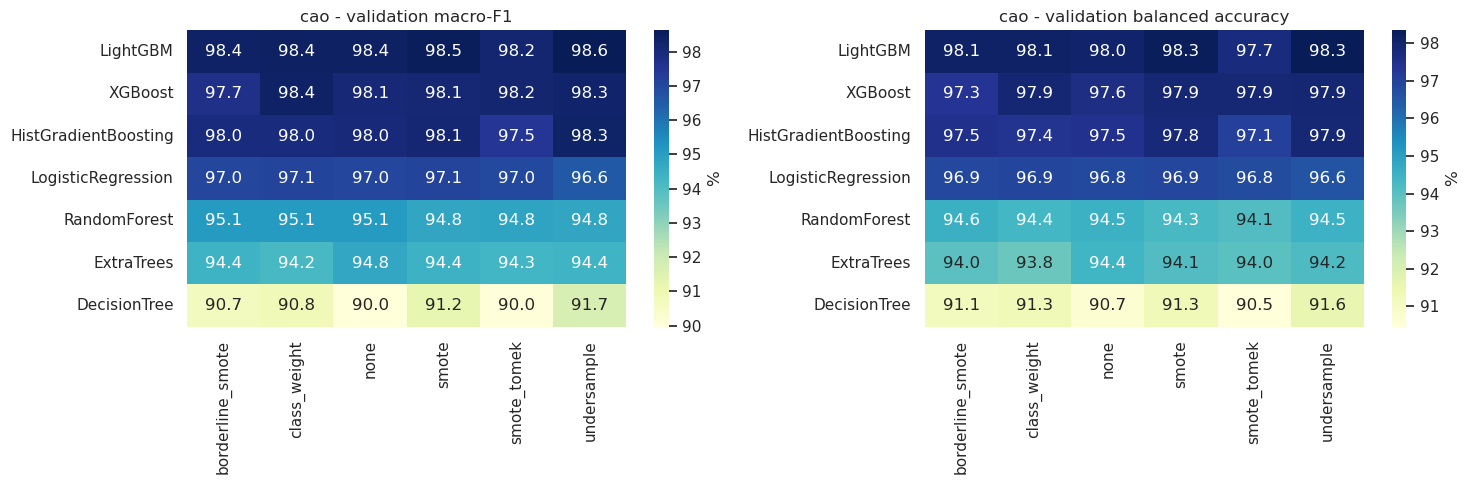

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes,
                             ["val_f1_macro", "val_balanced_accuracy"],
                             ["validation macro-F1", "validation balanced accuracy"]):
    piv = bench.pivot(index="model", columns="strategy", values=metric)
    piv = piv.reindex(index=piv.mean(axis=1).sort_values(ascending=False).index)
    sns.heatmap(100*piv, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
                cbar_kws={"label": "%"})
    ax.set_title(f"{DATASET} - {title}")
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(bench_dir / "model_x_strategy_heatmap.png", dpi=200)
plt.show()

In [5]:
best = bench.iloc[0]
print("best configuration by VALIDATION macro-F1:")
print(f"  model    : {best.model}")
print(f"  strategy : {best.strategy}")
print(f"  val  F1  : {100*best.val_f1_macro:.2f}%   acc {100*best.val_accuracy:.2f}%")
print(f"  test F1  : {100*best.test_f1_macro:.2f}%   acc {100*best.test_accuracy:.2f}%")
print(f"  train    : {best.train_seconds:.1f}s   inference {best.test_ms_per_sample:.4f} ms/sample")

gap = 100*(best.val_f1_macro - best.test_f1_macro)
print(f"\nval-test gap: {gap:+.2f} pp "
      f"({'healthy' if abs(gap) < 3 else 'investigate - possible overfit or split shift'})")

best configuration by VALIDATION macro-F1:
  model    : LightGBM
  strategy : undersample
  val  F1  : 98.62%   acc 99.04%
  test F1  : 98.90%   acc 99.06%
  train    : 40.2s   inference 0.0667 ms/sample

val-test gap: -0.27 pp (healthy)


## 3. Which balancing strategy wins, and by how much

Averaged over all seven classifiers, so the ranking reflects the strategy rather than
one lucky model pairing.

,val_f1,val_balacc,test_f1,train_s
strategy,,,,
undersample,96.09,95.86,97.00,42.7
smote,96.05,95.80,97.18,52.5
class_weight,96.00,95.68,97.24,44.1
none,95.91,95.65,97.01,45.1
borderline_smote,95.89,95.64,97.18,54.0
smote_tomek,95.71,95.44,96.80,51.3


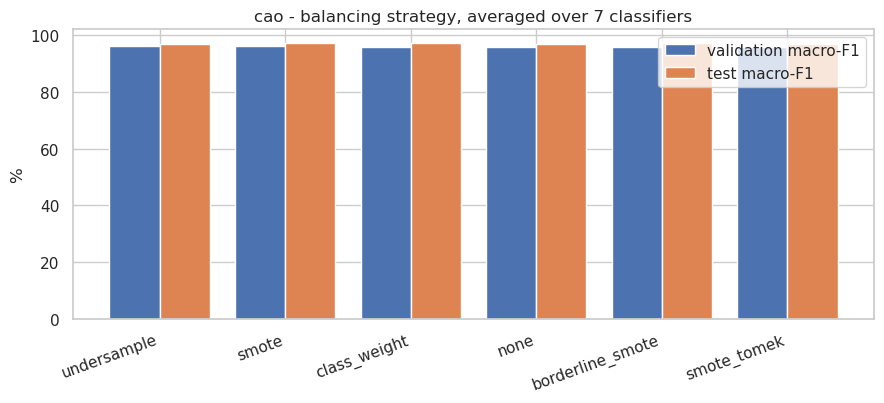

In [6]:
by_strat = (bench.groupby("strategy")
                 .agg(val_f1=("val_f1_macro", "mean"),
                      val_balacc=("val_balanced_accuracy", "mean"),
                      test_f1=("test_f1_macro", "mean"),
                      train_s=("train_seconds", "mean"))
                 .sort_values("val_f1", ascending=False))
display((100*by_strat[["val_f1", "val_balacc", "test_f1"]]).round(2)
        .join(by_strat[["train_s"]].round(1)))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(by_strat))
ax.bar(x - 0.2, 100*by_strat.val_f1, 0.4, label="validation macro-F1", color="#4C72B0")
ax.bar(x + 0.2, 100*by_strat.test_f1, 0.4, label="test macro-F1", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(by_strat.index, rotation=20, ha="right")
ax.set_ylabel("%"); ax.set_title(f"{DATASET} - balancing strategy, averaged over 7 classifiers")
ax.legend(); plt.tight_layout()
plt.savefig(bench_dir / "balancing_strategy_comparison.png", dpi=200)
plt.show()

## 4. Domain comparison

Each single domain against the multi-domain fusion, using the best (model, strategy) for
each. This is the evidence for the complementarity claim: fusion should beat every
individual domain.

In [7]:
domain_slices = {"time": slice(0, 112), "freq": slice(112, 202),
                 "tf": slice(202, 941), "spatial": slice(941, 1002)}
FAST_MODELS = ["LightGBM", "XGBoost", "RandomForest"]
FAST_STRATS = ["none", "class_weight"]

data_full = F.load(fuse_dir)          # domain slices refer to the un-selected matrix
Xf = data_full["X"]

dom_rows = []
for dname, sl in list(domain_slices.items()) + [("multi", slice(0, 1002))]:
    b = EV.benchmark(Xf[:, sl], y, split, model_names=FAST_MODELS,
                     strategies=FAST_STRATS, seed=C.SEED, verbose=False)
    top = b.iloc[0]
    dom_rows.append({
        "domain": dname, "n_features": (sl.stop - sl.start),
        "best_model": top.model, "best_strategy": top.strategy,
        "val_f1_macro": 100*top.val_f1_macro,
        "test_accuracy": 100*top.test_accuracy,
        "test_bal_acc": 100*top.test_balanced_accuracy,
        "test_f1_macro": 100*top.test_f1_macro,
        "train_seconds": top.train_seconds,
    })
    print(f"  {dname:8s} ({sl.stop-sl.start:4d} feat)  "
          f"val F1 {100*top.val_f1_macro:.2f}%  test F1 {100*top.test_f1_macro:.2f}%")

dom = pd.DataFrame(dom_rows).sort_values("test_f1_macro", ascending=False)
display(dom.round(2))
dom.to_csv(bench_dir / "domain_comparison.csv", index=False)

  time     ( 112 feat)  val F1 91.30%  test F1 90.69%
  freq     (  90 feat)  val F1 78.47%  test F1 79.51%
  tf       ( 739 feat)  val F1 95.78%  test F1 92.51%
  spatial  (  61 feat)  val F1 95.60%  test F1 95.42%
  multi    (1002 feat)  val F1 98.41%  test F1 98.89%


,domain,n_features,best_model,best_strategy,val_f1_macro,test_accuracy,test_bal_acc,test_f1_macro,train_seconds
4,multi,1002,LightGBM,class_weight,98.41,99.06,99.05,98.89,41.31
3,spatial,61,LightGBM,none,95.60,96.34,95.57,95.42,5.03
2,tf,739,LightGBM,class_weight,95.78,94.34,92.53,92.51,41.16
0,time,112,LightGBM,none,91.30,92.29,91.16,90.69,9.45
1,freq,90,LightGBM,none,78.47,82.20,81.00,79.51,11.55


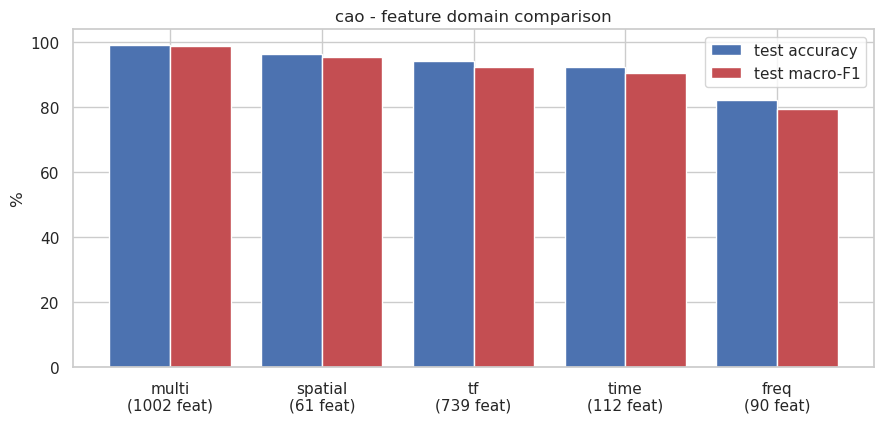

multi-domain beats the best single domain (spatial) by +3.46 pp macro-F1


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.4))
d = dom.set_index("domain")
x = np.arange(len(d))
ax.bar(x - 0.2, d.test_accuracy, 0.4, label="test accuracy", color="#4C72B0")
ax.bar(x + 0.2, d.test_f1_macro, 0.4, label="test macro-F1", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels([f"{i}\n({n} feat)" for i, n in zip(d.index, d.n_features)])
ax.set_ylabel("%"); ax.set_title(f"{DATASET} - feature domain comparison")
ax.legend(); plt.tight_layout()
plt.savefig(bench_dir / "domain_comparison.png", dpi=200)
plt.show()

multi = d.loc["multi", "test_f1_macro"]
best_single = d.drop("multi").test_f1_macro.max()
best_single_name = d.drop("multi").test_f1_macro.idxmax()
print(f"multi-domain beats the best single domain ({best_single_name}) by "
      f"{multi - best_single:+.2f} pp macro-F1")

## 5. Grouped cross-validation for the winning configuration

Folds respect the same group structure as the split, so the CV estimate inherits the
leakage guarantees rather than quietly discarding them.

In [9]:
group_col = "group_id" if "group_id" in mani.columns else C.DATASETS[DATASET].group_key
groups = mani[group_col].to_numpy()

cv = EV.grouped_cv(X[tr], y[tr], groups[tr], best.model, best.strategy,
                   n_splits=C.CV_FOLDS, seed=C.SEED)
display(cv[["fold", "accuracy", "balanced_accuracy", "f1_macro"]].round(4))

mean, lo, hi = EV.ci95(cv.f1_macro)
print(f"\n{C.CV_FOLDS}-fold grouped CV macro-F1: {100*mean:.2f}%  95% CI [{100*lo:.2f}, {100*hi:.2f}]")
print(f"held-out test macro-F1              : {100*best.test_f1_macro:.2f}%")
print(f"generalisation gap                  : {100*(best.test_f1_macro - mean):+.2f} pp")
cv.to_csv(bench_dir / "cv_best_config.csv", index=False)

,fold,accuracy,balanced_accuracy,f1_macro
0,0,0.9795,0.9793,0.9779
1,1,0.9853,0.9839,0.9841
2,2,0.9906,0.9907,0.9901
3,3,0.9875,0.9855,0.9865
4,4,0.9883,0.9869,0.9870



5-fold grouped CV macro-F1: 98.51%  95% CI [98.11, 98.91]
held-out test macro-F1              : 98.90%
generalisation gap                  : +0.38 pp


## 6. Save

In [10]:
summary = {
    "dataset": DATASET,
    "feature_set": "consensus" if USE_SELECTED else "multi_domain_full",
    "n_features": int(X.shape[1]),
    "best_model": best.model,
    "best_strategy": best.strategy,
    "val_f1_macro": float(best.val_f1_macro),
    "test_accuracy": float(best.test_accuracy),
    "test_balanced_accuracy": float(best.test_balanced_accuracy),
    "test_f1_macro": float(best.test_f1_macro),
    "cv_f1_macro_mean": float(mean), "cv_f1_ci95": [float(lo), float(hi)],
    "train_seconds": float(best.train_seconds),
    "inference_ms_per_sample": float(best.test_ms_per_sample),
}
(bench_dir / "best_config.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
by_strat.to_csv(bench_dir / "balancing_summary.csv")
print(json.dumps(summary, indent=2))

{
  "dataset": "cao",
  "feature_set": "multi_domain_full",
  "n_features": 1002,
  "best_model": "LightGBM",
  "best_strategy": "undersample",
  "val_f1_macro": 0.9862161376391029,
  "test_accuracy": 0.9905712701053799,
  "test_balanced_accuracy": 0.98979725807474,
  "test_f1_macro": 0.9889653827503903,
  "cv_f1_macro_mean": 0.9851223310391939,
  "cv_f1_ci95": [
    0.9811451101665082,
    0.9890995519118796
  ],
  "train_seconds": 40.234404790971894,
  "inference_ms_per_sample": 0.06670693733124552
}


---
**Next:** `07_final_model_and_ablation.ipynb` - per-class analysis, confusion matrices
and the class-removal ablation.